# Initialize

In [5]:
%pip install matplotlib pyyaml

Note: you may need to restart the kernel to use updated packages.


In [6]:
#Imports
import os
import numpy as np
import yaml
import shutil
import re
import matplotlib.pyplot as plt
from datetime import datetime
#Helper
def get_directories(directory, regex_search=""):
    """
    This function returns a list of directories from the specified directory that match the regular expression search pattern.
    
    Parameters:
    directory (str): The directory path where to look for directories.
    regex_search (str, optional): The regular expression pattern to match. Default is an empty string, which means all directories are included.
    
    Returns:
    list: A list of directory names that match the regular expression search pattern.
    """
    directories = None
    if os.path.exists(directory):
        directories = [name for name in os.listdir(directory) if os.path.isdir(os.path.join(directory, name)) and len(re.findall(regex_search, name))>0]
    else:
        print(f"Directory does not exist: {directory}")
    return directories

def get_files(directory, ending="", regex_search=""):
    """
    This function returns a list of files from the specified directory that match the regular expression search pattern and have the specified file ending.
    
    Parameters:
    directory (str): The directory path where to look for files.
    ending (str, optional): The file ending to match. Default is '', which means all file endings are included.
    regex_search (str, optional): The regular expression pattern to match. Default is an empty string, which means all files are included.
    
    Returns:
    list: A list of file names that match the regular expression search pattern and have the specified file ending.
    """
    files_list = None
    if os.path.exists(directory):
        files_list = [name for name in os.listdir(directory) if os.path.isfile(os.path.join(directory, name)) and len(re.findall(regex_search, name))>0 and name.endswith(ending)]
    else:
        print(f"Directory does not exist: {directory}")
    return files_list

def sliding_window(arr, window_size, step_size=1):
    """
    Generate sliding windows of size window_size over an array.

    Args:
        arr (list): The input array.
        k (int): The size of the sliding window.

    Yields:
        list: A sliding window of size window_size.

    Returns:
        None: If the length of the array is less than window_size.
    """
    n = len(arr)
    if n < window_size:
        return None
    window = arr[:window_size]
    yield window
    for i in range(window_size, n, step_size):
        window = np.append(window[step_size:], arr[i])
        yield window

def sliding_mean_std(arr, window_size):
    """
    Compute the sliding window mean and standard deviation of an array.

    Parameters:
    arr (array-like): Input array.
    k (int): Window size.

    Returns:
    list: A list of tuples containing the mean and standard deviation of each window.
    """
    num_windows = len(arr) - window_size + 1
    mean_stds = np.zeros([num_windows, 2])
    for num, window in enumerate(sliding_window(arr, window_size)):
        mean_stds[num, 0] = np.mean(window)
        mean_stds[num, 1] = np.std(window)
    return np.array(mean_stds)

def traces(fluorescence, animal_id, session_id, unit_id="all", 
            num_cells="all", fluorescence_type="", fps=30, dpi=300):
    # plot fluorescence
    fluorescence = np.array(fluorescence)
    fluorescence = np.transpose(fluorescence) if len(fluorescence.shape)==2 else fluorescence
    plt.figure()
    plt.figure(figsize=(12, 7))
    if num_cells != "all":
        plt.plot(fluorescence[:, :int(num_cells)])
    else:
        plt.plot(fluorescence)

    seconds = 5
    num_frames = fps*seconds
    num_x_ticks = 50
    written_label_steps = 2

    x_time = [int(frame/num_frames)*seconds for frame in range(len(fluorescence)) if frame%num_frames==0] 
    steps = round(len(x_time)/(2*num_x_ticks))
    x_time_shortened = x_time[::steps]
    x_pos = np.arange(0, len(fluorescence), num_frames)[::steps] 
    
    file_name = f"{animal_id} {session_id}"
    title = f"Bursts from {file_name} {fluorescence_type}"
    xlabel=f"seconds"
    ylabel='fluorescence based on Ca in Cell'
    x_labels = [time if num%written_label_steps==0 else "" for num, time in enumerate(x_time_shortened)]
    plt.xticks(x_pos, x_labels, rotation=40, fontsize=8)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    #plt.savefig(os.path.join(self.save_dir, title.replace(" ", "_")+".png"), dpi=dpi)
    plt.show()
    plt.close()

def plot_velocity( velocity, average=False, window_size=30):
    velocity_lable = "Velocity"
    plot_velocity = velocity
    if average:
        plot_velocity = sliding_mean_std(velocity, window_size=window_size)[:, 0]
        velocity_lable = 'Averaged Velocity'

    plt.figure(figsize=(15, 15))  # Adjust the figure size as needed

    # Plot the averaged velocity data with labels
    plt.plot(plot_velocity, label=velocity_lable)
    plt.xlabel('Frames')
    plt.ylabel('Velocity')
    plt.title('Velocity Data')
    plt.legend()
    plt.grid(True, color="gray")

    plt.show()

def np_load_if_exists(fpath, allow_pickle=True):
    return np.load(fpath, allow_pickle=allow_pickle) if os.path.exists(fpath) else None

def num_to_date(date_string):
    if type(date_string) != str:
        date_string = str(date_string)
    date = datetime.strptime(date_string, '%Y%m%d')
    return date

#Classes
class Animal:
    """
    Represents an animal in a research experiment.

    Attributes:
        root_dir (str): The root directory where animal data is stored.
        sessions (dict): A dictionary to store information about sessions associated with the animal.
        cohort_year (int): The year the animal was part of a cohort.
        dob (str): The date of birth of the animal.
        animal_id (str): A unique identifier for the animal.
        sex (str): The gender of the animal.

    Methods:
        __init__(self, yaml_file_path, print_loading=True):
            Initialize an Animal object by loading metadata from a YAML file.

        load_metadata(self, yaml_path):
            Load metadata from a YAML file and set attributes for the Animal object.

        get_session_data(self, path, print_loading=True):
            Get session data associated with the animal from a specified directory.

    Parameters:
        - yaml_file_path (str): The path to the YAML file containing animal metadata.
        - print_loading (bool, optional): If True, print a message when an animal is added.

    Returns:
        None
    """
    root_dir = "/scicore/projects/donafl00-calcium/Users/Sergej/Steffen_Experiments" 

    def __init__(self, yaml_file_path, print_loading=True) -> None:
        self.sessions = {}
        self.cohort_year = None
        self.dob = None
        self.animal_id = None 
        self.sex = None
        self.load_metadata(yaml_file_path)
        self.animal_dir = os.path.join(Animal.root_dir, self.animal_id)
        if print_loading:
            print(f"Added animal: {self.animal_id}")


    def load_metadata(self, yaml_path):
        with open(yaml_path, "r") as yaml_file:
            animal_metadata_dict = yaml.safe_load(yaml_file)

        # Load any additional metadata into session object
        for variable_name, value in animal_metadata_dict.items():
            setattr(self, variable_name, value)

        cohort_year = animal_metadata_dict["cohort_year"]
        self.cohort_year = int(cohort_year) if type(cohort_year)==str else int(cohort_year[0]) if type(cohort_year)==list else cohort_year
        self.dob = animal_metadata_dict["dob"]
        for animal_id_key in ["name", "animal_id"]:
            if animal_id_key in animal_metadata_dict.keys():
                self.animal_id = animal_metadata_dict["animal_id"]
        self.sex = animal_metadata_dict["sex"]
        return animal_metadata_dict
    
    def get_session_data(self, path, print_loading=True):
        session_yaml_fnames = get_files(path, ending=".yaml")
        match = None
        session = None
        if session_yaml_fnames:
            for session_yaml_fname in session_yaml_fnames:
                match = True
                session_yaml_path = os.path.join(path, session_yaml_fname)
                session = Session(session_yaml_path,
                                animal_id=self.animal_id,
                                print_loading=print_loading)
                #checking if sessin is correct
                if str(session.date) not in session_yaml_fname:
                    print(f"Yaml file naming does not match session date: {session_yaml_fname} != {session.date}")
                    match = False
                if match:
                    session.pday = (num_to_date(session.date) - num_to_date(self.dob)).days
                    break
                else:
                    print(f"Reading next yaml file")
        if match:
            self.sessions[session.session_id] = session
            self.sessions = {session_id: session for session_id, session in sorted(self.sessions.items())}
        else:
            print(f"No matching yaml file found. Skipping session path {path}")
        return session

class Session:
    """
    A class for managing and loading session metadata and data for an experimental session.

    Attributes:
        cabincorr_fname (str): The name of the binary traces file.
        animal_id (str): The ID of the animal associated with the session.
        yaml_file_path (str): The path to the YAML file containing session metadata.
        image_x_size (int): The width of the image in pixels.
        image_y_size (int): The height of the image in pixels.
        functional_chan (int): The functional channel.
        session_id (str): The unique identifier for the session.
        fps (float): Frames per second for the session.
        date (str): The date of the session.
        pday (str): The postnatal day of the session.
        clean (bool): Indicates whether data is cleaned.
        F_detrended (numpy.ndarray): Detrended fluorescence data.
        F_upphase (numpy.ndarray): Upphase fluorescence data.
        iscell (numpy.ndarray): Indicates whether a cell is classified.
        cell_drying (numpy.ndarray): Indicates the drying status of cells.
        session_dir (str): The directory path for the session.

    Methods:
        __init__(self, yaml_file_path, animal_id=None, print_loading=True):
            Initializes a Session object and loads session metadata.
        load_metadata(self, yaml_path):
            Loads session metadata from a YAML file.
        load_fps(self):
            Loads the frames per second (fps) for the session.
        load_iscell(self):
            Loads the cell classification data.
        load_cell_drying(self):
            Loads information about cell drying.
        load_fluorescence(self, clean=False):
            Loads fluorescence data, optionally applying cleaning filters.

    """
    cabincorr_fname = "binarized_traces.npz"

    def __init__(self, yaml_file_path, animal_id=None, print_loading=True) -> None:
        self.animal_id = animal_id
        self.yaml_file_path = yaml_file_path
        self.image_x_size = 512
        self.image_y_size = 512
        self.functional_chan = 1
        self.session_id = None
        self.fps = None
        self.date = None
        self.pday = None
        self.load_metadata(yaml_file_path)
                     
        self.clean = False
        self.F_detrended, self.F_upphase = None, None
        self.cell_drying = None
        self.velocity = None
        self.session_dir = os.path.join(Animal.root_dir, self.animal_id, self.session_id)
        if print_loading:
            #print(f"Initialized {updated_txt}session: {animal_id} {self.session_id}")
            print(f"Initialized session: {animal_id} {self.session_id}")

    def load_metadata(self, yaml_path):
        with open(yaml_path, "r") as yaml_file:
            session_metadata_dict = yaml.safe_load(yaml_file)

        # Load any additional metadata into session object
        for variable_name, value in session_metadata_dict.items():
            setattr(self, variable_name, value)
        if not self.session_id:
            self.session_id = str(self.date)
        needed_variables = ["date"]
        for needed_variable in needed_variables:
            defined_variable = getattr(self, needed_variable)
            if defined_variable == None:
                raise KeyError(f"Variable {needed_variable} is not defined in yaml file {yaml_path}")
    
    def load_fps(self):
        if self.fps:
            return self.fps,
        fps_path = os.path.join(self.session_dir, "fps.npy")
        self.fps = np_load_if_exists(fps_path)
        return self.fps
            
    def load_cell_drying(self):
        if not type(self.cell_drying) == np.ndarray:
            cell_drying_path = os.path.join(self.session_dir, "cell_drying.npy")
            self.cell_drying = np_load_if_exists(cell_drying_path)
        return self.cell_drying

    def load_velocity(self):
        if not type(self.velocity) == np.ndarray:
            velocity_path = os.path.join(self.session_dir, "merged_velocity.npy")
            self.velocity = np_load_if_exists(velocity_path)
        return self.velocity
    
    def load_fluoresence(self, clean=False):
        if type(self.F_detrended)==np.ndarray and clean==self.clean:
            return self.F_detrended, self.F_upphase
        self.clean = clean
        F_detrended_path = os.path.join(self.session_dir, "F_detrended.npy")
        F_upphase_path = os.path.join(self.session_dir, "F_upphase.npy")
        self.F_detrended = np_load_if_exists(F_detrended_path)
        self.F_upphase = np_load_if_exists(F_upphase_path)
        if clean:
            self.del_iscell()
            cell_drying = self.load_cell_drying()
            self.F_detrended = self.F_detrended[cell_drying==False]
            self.F_upphase = self.F_upphase[cell_drying==False]
        return self.F_detrended, self.F_upphase


In [2]:
def load_all(root_dir, wanted_animal_ids=["all"], wanted_session_ids=["all"], print_loading=True):
    """
    Loads animal data from the specified root directory for the given animal IDs.

    Parameters:
    - root_dir (string): The root directory path where the animal data is stored.
    - animal_ids (list, optional): A list of animal IDs to load. Default is ["all"].
    Returns:
    - animals_dict (dict): A dictionary containing animal IDs as keys and corresponding Animal objects as values.
    """
    present_animal_ids = get_directories(root_dir, regex_search="DON-")
    animals_dict = {}

    # Search for animal_ids
    for animal_id in present_animal_ids:
        if animal_id in wanted_animal_ids or "all" in wanted_animal_ids:
            sessions_root_path = os.path.join(root_dir, animal_id)
            present_sessions = get_directories(sessions_root_path)
            yaml_file_name = os.path.join(root_dir, animal_id, f"{animal_id}.yaml")
            animal = Animal(yaml_file_name, print_loading=print_loading)
            Animal.root_dir = root_dir
            # Search for 2P Sessions
            for session in present_sessions:
                if session in wanted_session_ids or "all" in wanted_session_ids:
                    session_path = os.path.join(sessions_root_path, session)
                    animal.get_session_data(session_path, 
                                            print_loading=print_loading)
            animals_dict[animal_id] = animal
    return animals_dict

# Work Examples

## Loading

### Animals

In [30]:
# Root directory should be changed in Animal class too, if necessary
#root_dir = r"\\toucan-all.scicore.unibas.ch\donafl00-calcium$\Users\Sergej\Steffen_Experiments\rodrigo"
root_dir = "/scicore/projects/donafl00-calcium/Users/Sergej/Steffen_Experiments/cecillia" 
Animal.root_dir = root_dir
mice21 = ["DON-002865", "DON-003165", "DON-003343", "DON-006084", "DON-006085", "DON-006087"]
mice22 = ["DON-008497", "DON-008498", "DON-008499", "DON-009191", "DON-009192", "DON-010473", "DON-010477"]
mice23 = ["DON-014837", "DON-014838", "DON-014840", "DON-014847", "DON-014849", "DON-015078", "DON-015079"]

In [31]:
# create animal and session objects and load metadata
# for mice with the id "DON-002865" and all sessions
wanted_animal_ids = ["DON-002865"]
animals = load_all(root_dir, wanted_animal_ids=wanted_animal_ids, wanted_session_ids=["all"], print_loading=True)

Added animal: DON-002865
Initialized session: DON-002865 20210217
Initialized session: DON-002865 20210227
Initialized session: DON-002865 20210213
Initialized session: DON-002865 20210223
Initialized session: DON-002865 20210302
Initialized session: DON-002865 20210218
Initialized session: DON-002865 20210228
Initialized session: DON-002865 20210211
Initialized session: DON-002865 20210303
Initialized session: DON-002865 20210216
Initialized session: DON-002865 20210226
Initialized session: DON-002865 20210222
Initialized session: DON-002865 20210301
Initialized session: DON-002865 20210214
Initialized session: DON-002865 20210224
Initialized session: DON-002865 20210210
Initialized session: DON-002865 20210220
Initialized session: DON-002865 20210219
Initialized session: DON-002865 20210215
Initialized session: DON-002865 20210225
Initialized session: DON-002865 20210212


### FPS

In [32]:
# example to load fps for every session for every mouse (stops after 1 session)
for animal_id, animal in animals.items():
    for session_id, session in animal.sessions.items():
        # load fps from session
        fps = session.load_fps()
        print(f"{animal_id} {session_id} fps: {fps}")
        print(f"{session.animal_id} {session.session_id} fps: {session.fps}")
        break
    break

DON-002865 20210210 fps: 30.966814176218747
DON-002865 20210210 fps: 30.966814176218747


### Fluoresence

In [33]:
# create animal and session objects and load metadata
# for mice from cohort 2021 and 2022 and all sessions
wanted_animal_ids = mice21+mice22+mice23
animals = load_all(root_dir, wanted_animal_ids=wanted_animal_ids, wanted_session_ids=["all"], print_loading=False)

No matching yaml file found. Skipping session path /scicore/projects/donafl00-calcium/Users/Sergej/Steffen_Experiments/cecillia/DON-014838/20230303


<Figure size 640x480 with 0 Axes>

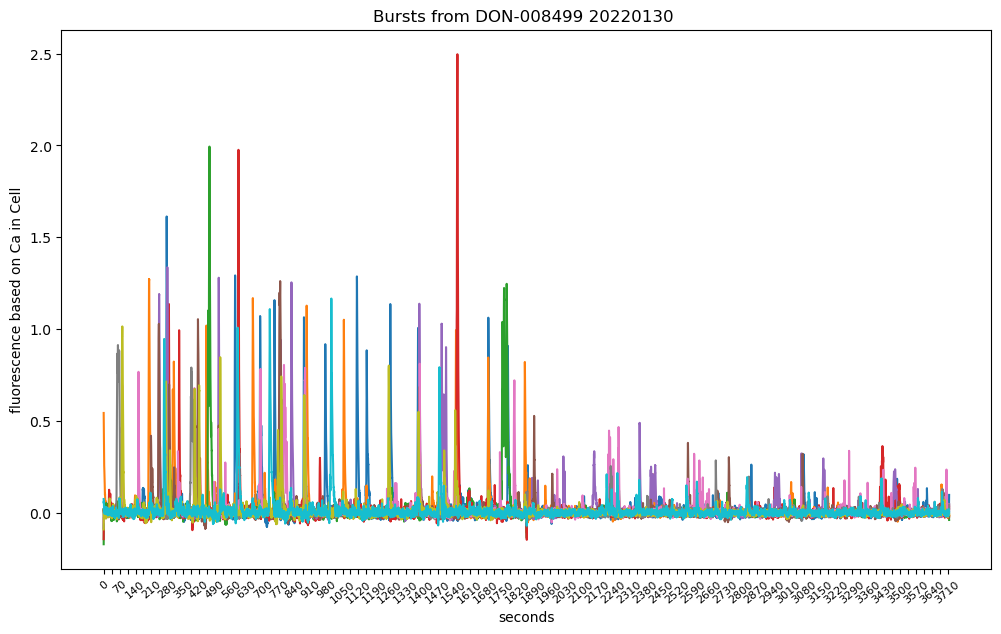

<Figure size 640x480 with 0 Axes>

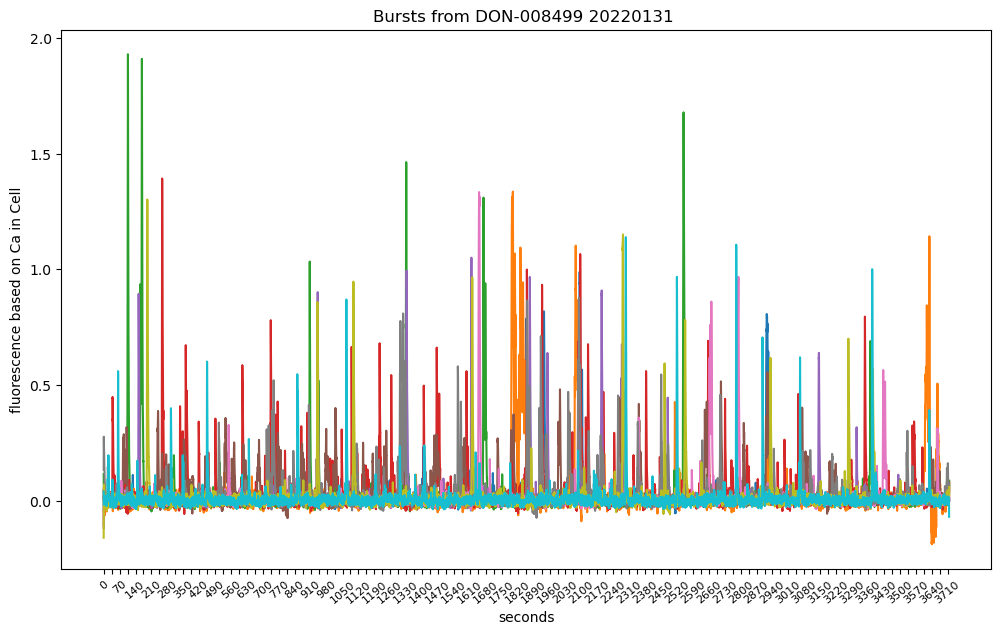

<Figure size 640x480 with 0 Axes>

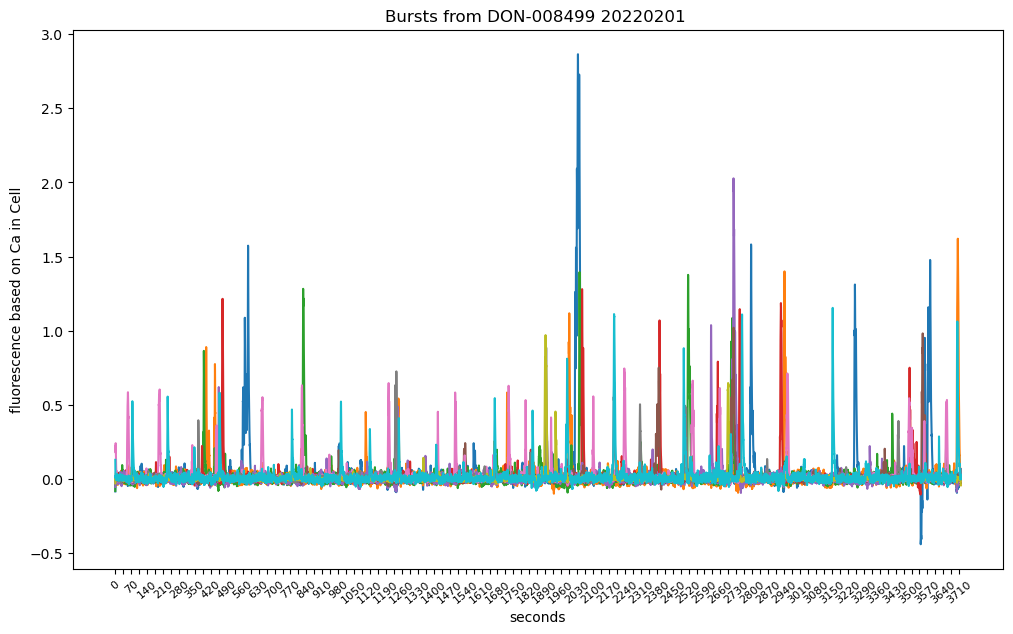

KeyboardInterrupt: 

In [36]:
# plot fluoresence of 10 cells for 1 session of every mouse
for animal_id, animal in animals.items():
    if animal.cohort_year in [2021, 2022]:
        for session_id, session in animal.sessions.items():
            # load fluoresence data
            session.load_fluoresence(clean=True)
            traces(session.F_detrended, session.animal_id, session.session_id, num_cells=10)
            break
        break

### Velocities

In [4]:
root_dir = "/scicore/projects/donafl00-calcium/Users/Sergej/Steffen_Experiments/cecillia" 
Animal.root_dir = root_dir
wanted_animal_ids = ["DON-014847"]
animals = load_all(root_dir, wanted_animal_ids=wanted_animal_ids, wanted_session_ids=["all"], print_loading=True)

Added animal: DON-014847
Initialized session: DON-014847 20230211
Initialized session: DON-014847 20230225
Initialized session: DON-014847 20230214
Initialized session: DON-014847 20230311
Initialized session: DON-014847 20230217
Initialized session: DON-014847 20230127
Initialized session: DON-014847 20230130
Initialized session: DON-014847 20230303
Initialized session: DON-014847 20230210
Initialized session: DON-014847 20230317
Initialized session: DON-014847 20230213
Initialized session: DON-014847 20230202
Initialized session: DON-014847 20230205
Initialized session: DON-014847 20230313
Initialized session: DON-014847 20230219
Initialized session: DON-014847 20230208
Initialized session: DON-014847 20230316
Initialized session: DON-014847 20230319
Initialized session: DON-014847 20230201
Initialized session: DON-014847 20230215
Initialized session: DON-014847 20230325
Initialized session: DON-014847 20230204
Initialized session: DON-014847 20230221
Initialized session: DON-014847 

In [7]:
for animal_id, animal in animals.items():
    for session_id, session in animal.sessions.items():
        velocity = session.load_velocity()
        if type(velocity)==np.ndarray:
            print(velocity.shape)
            break

(74322,)


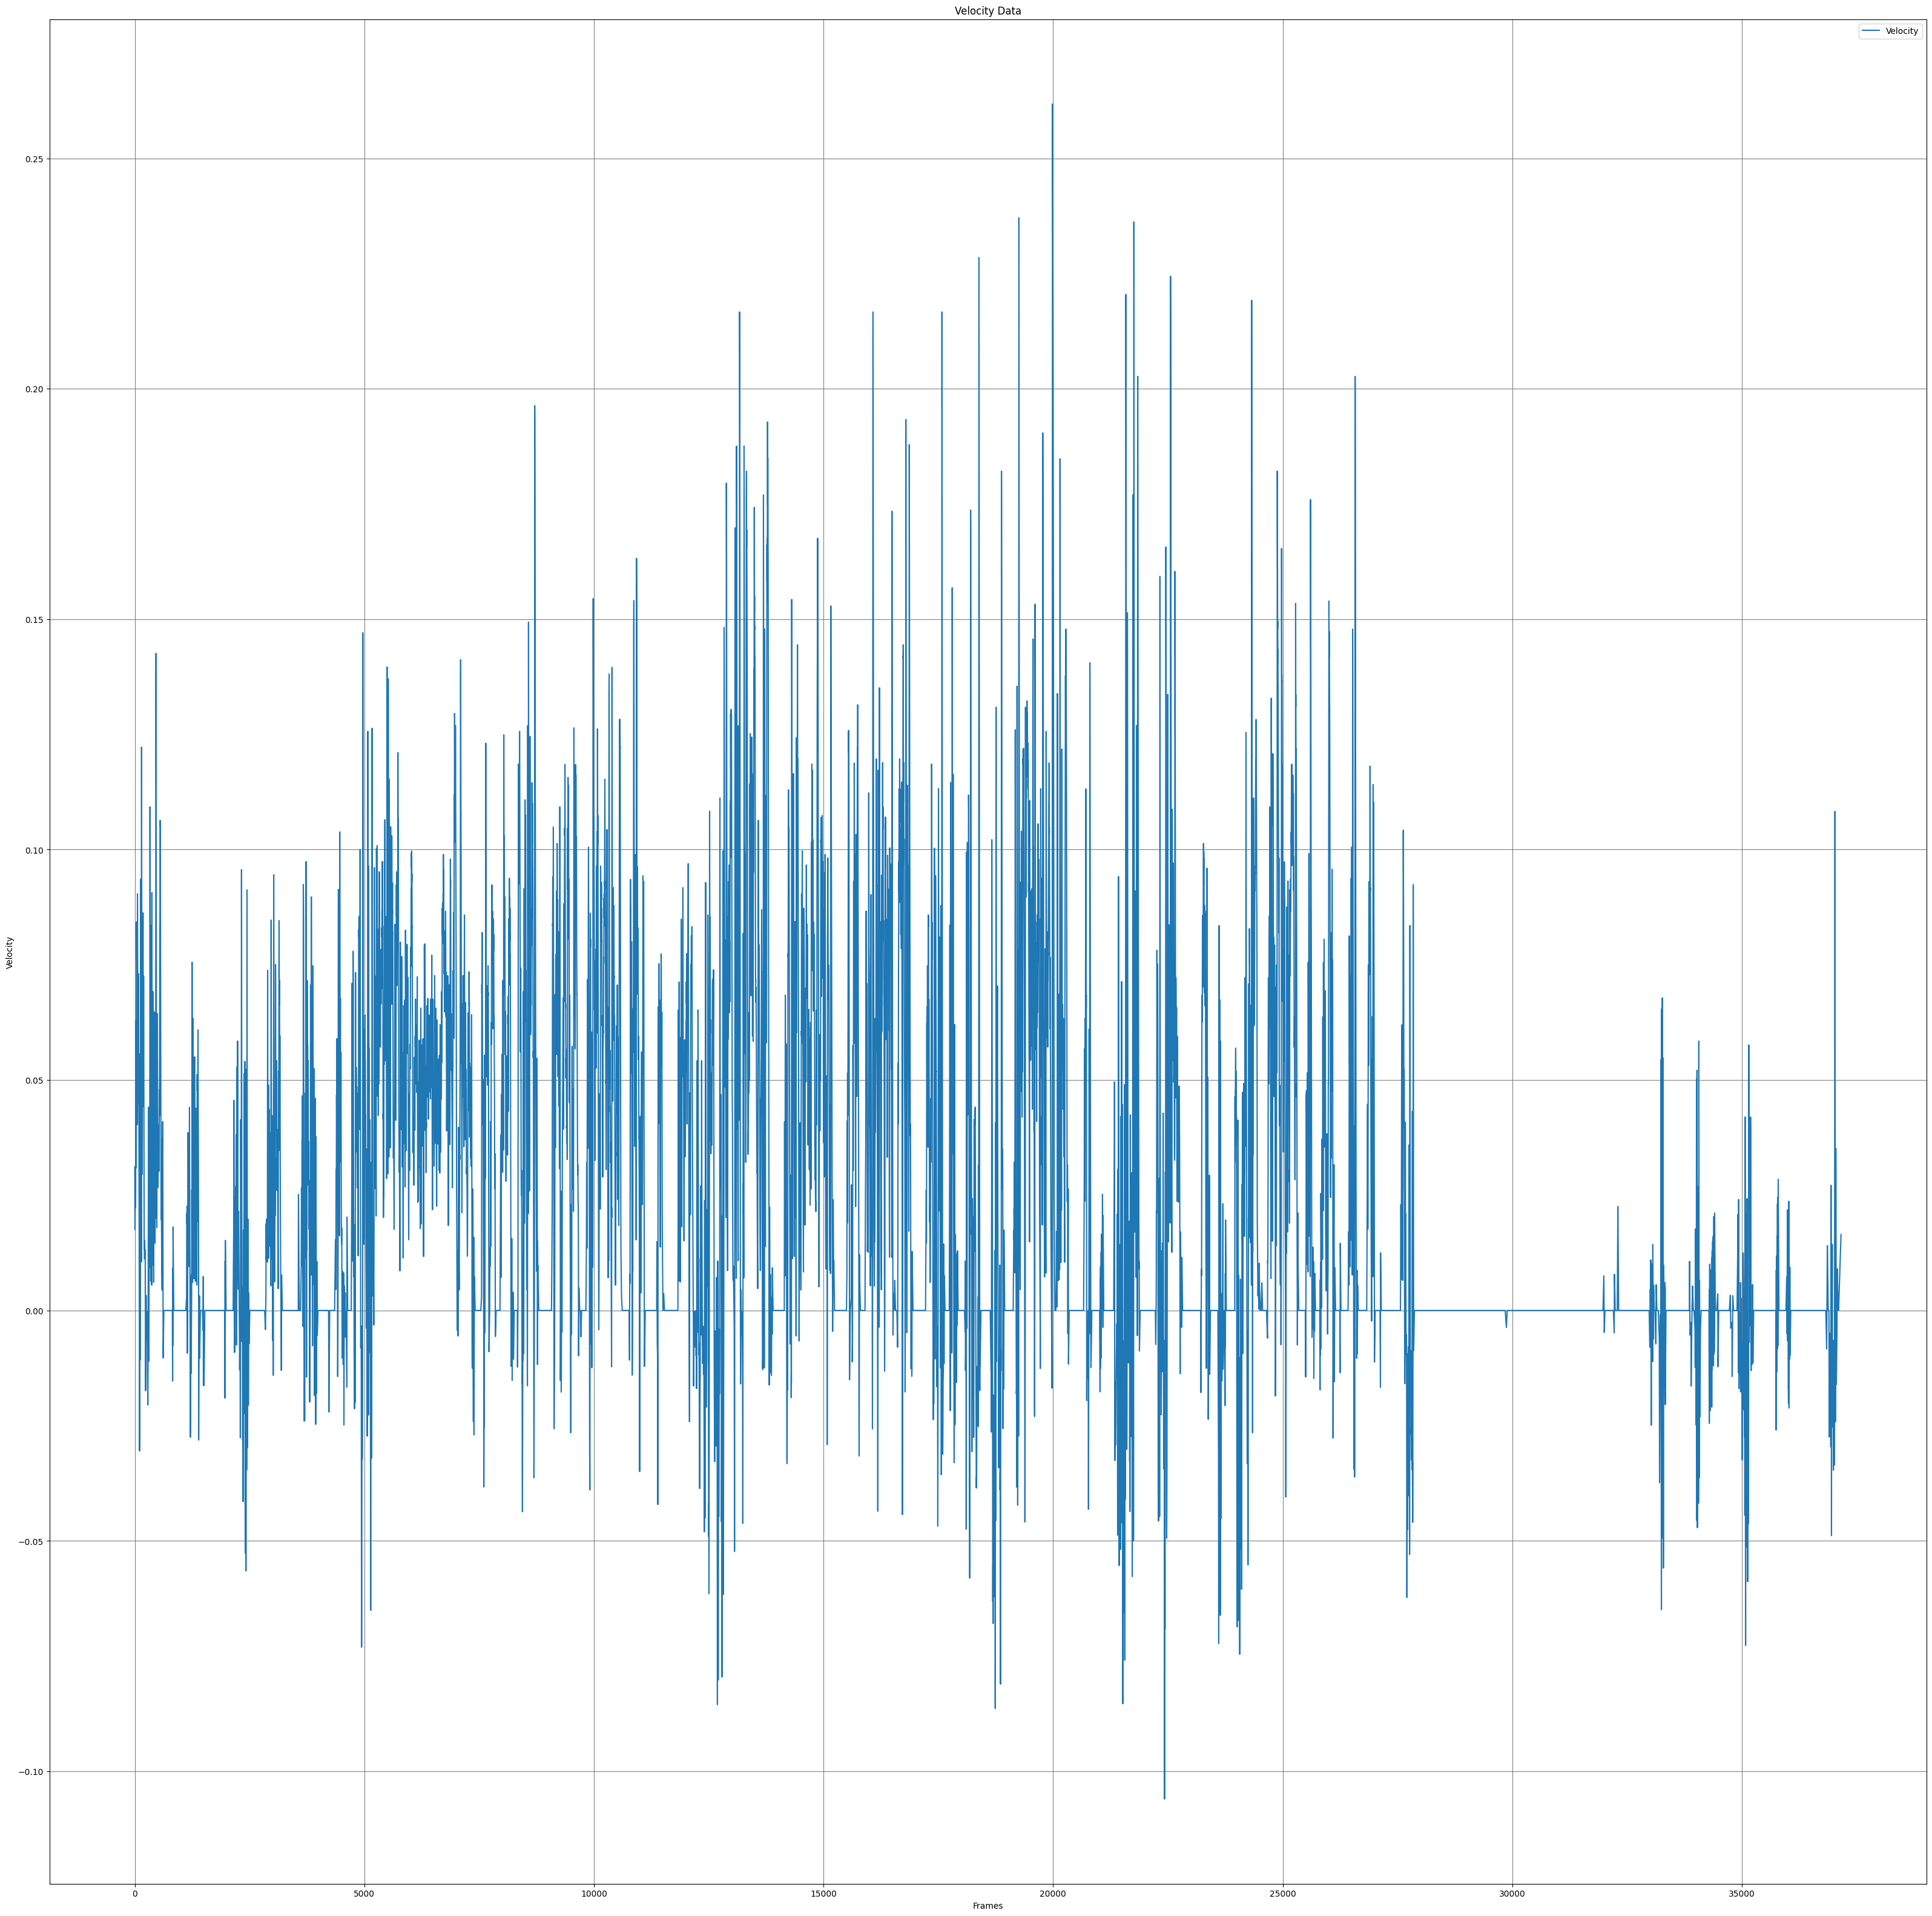

In [13]:
plot_velocity(velocity)

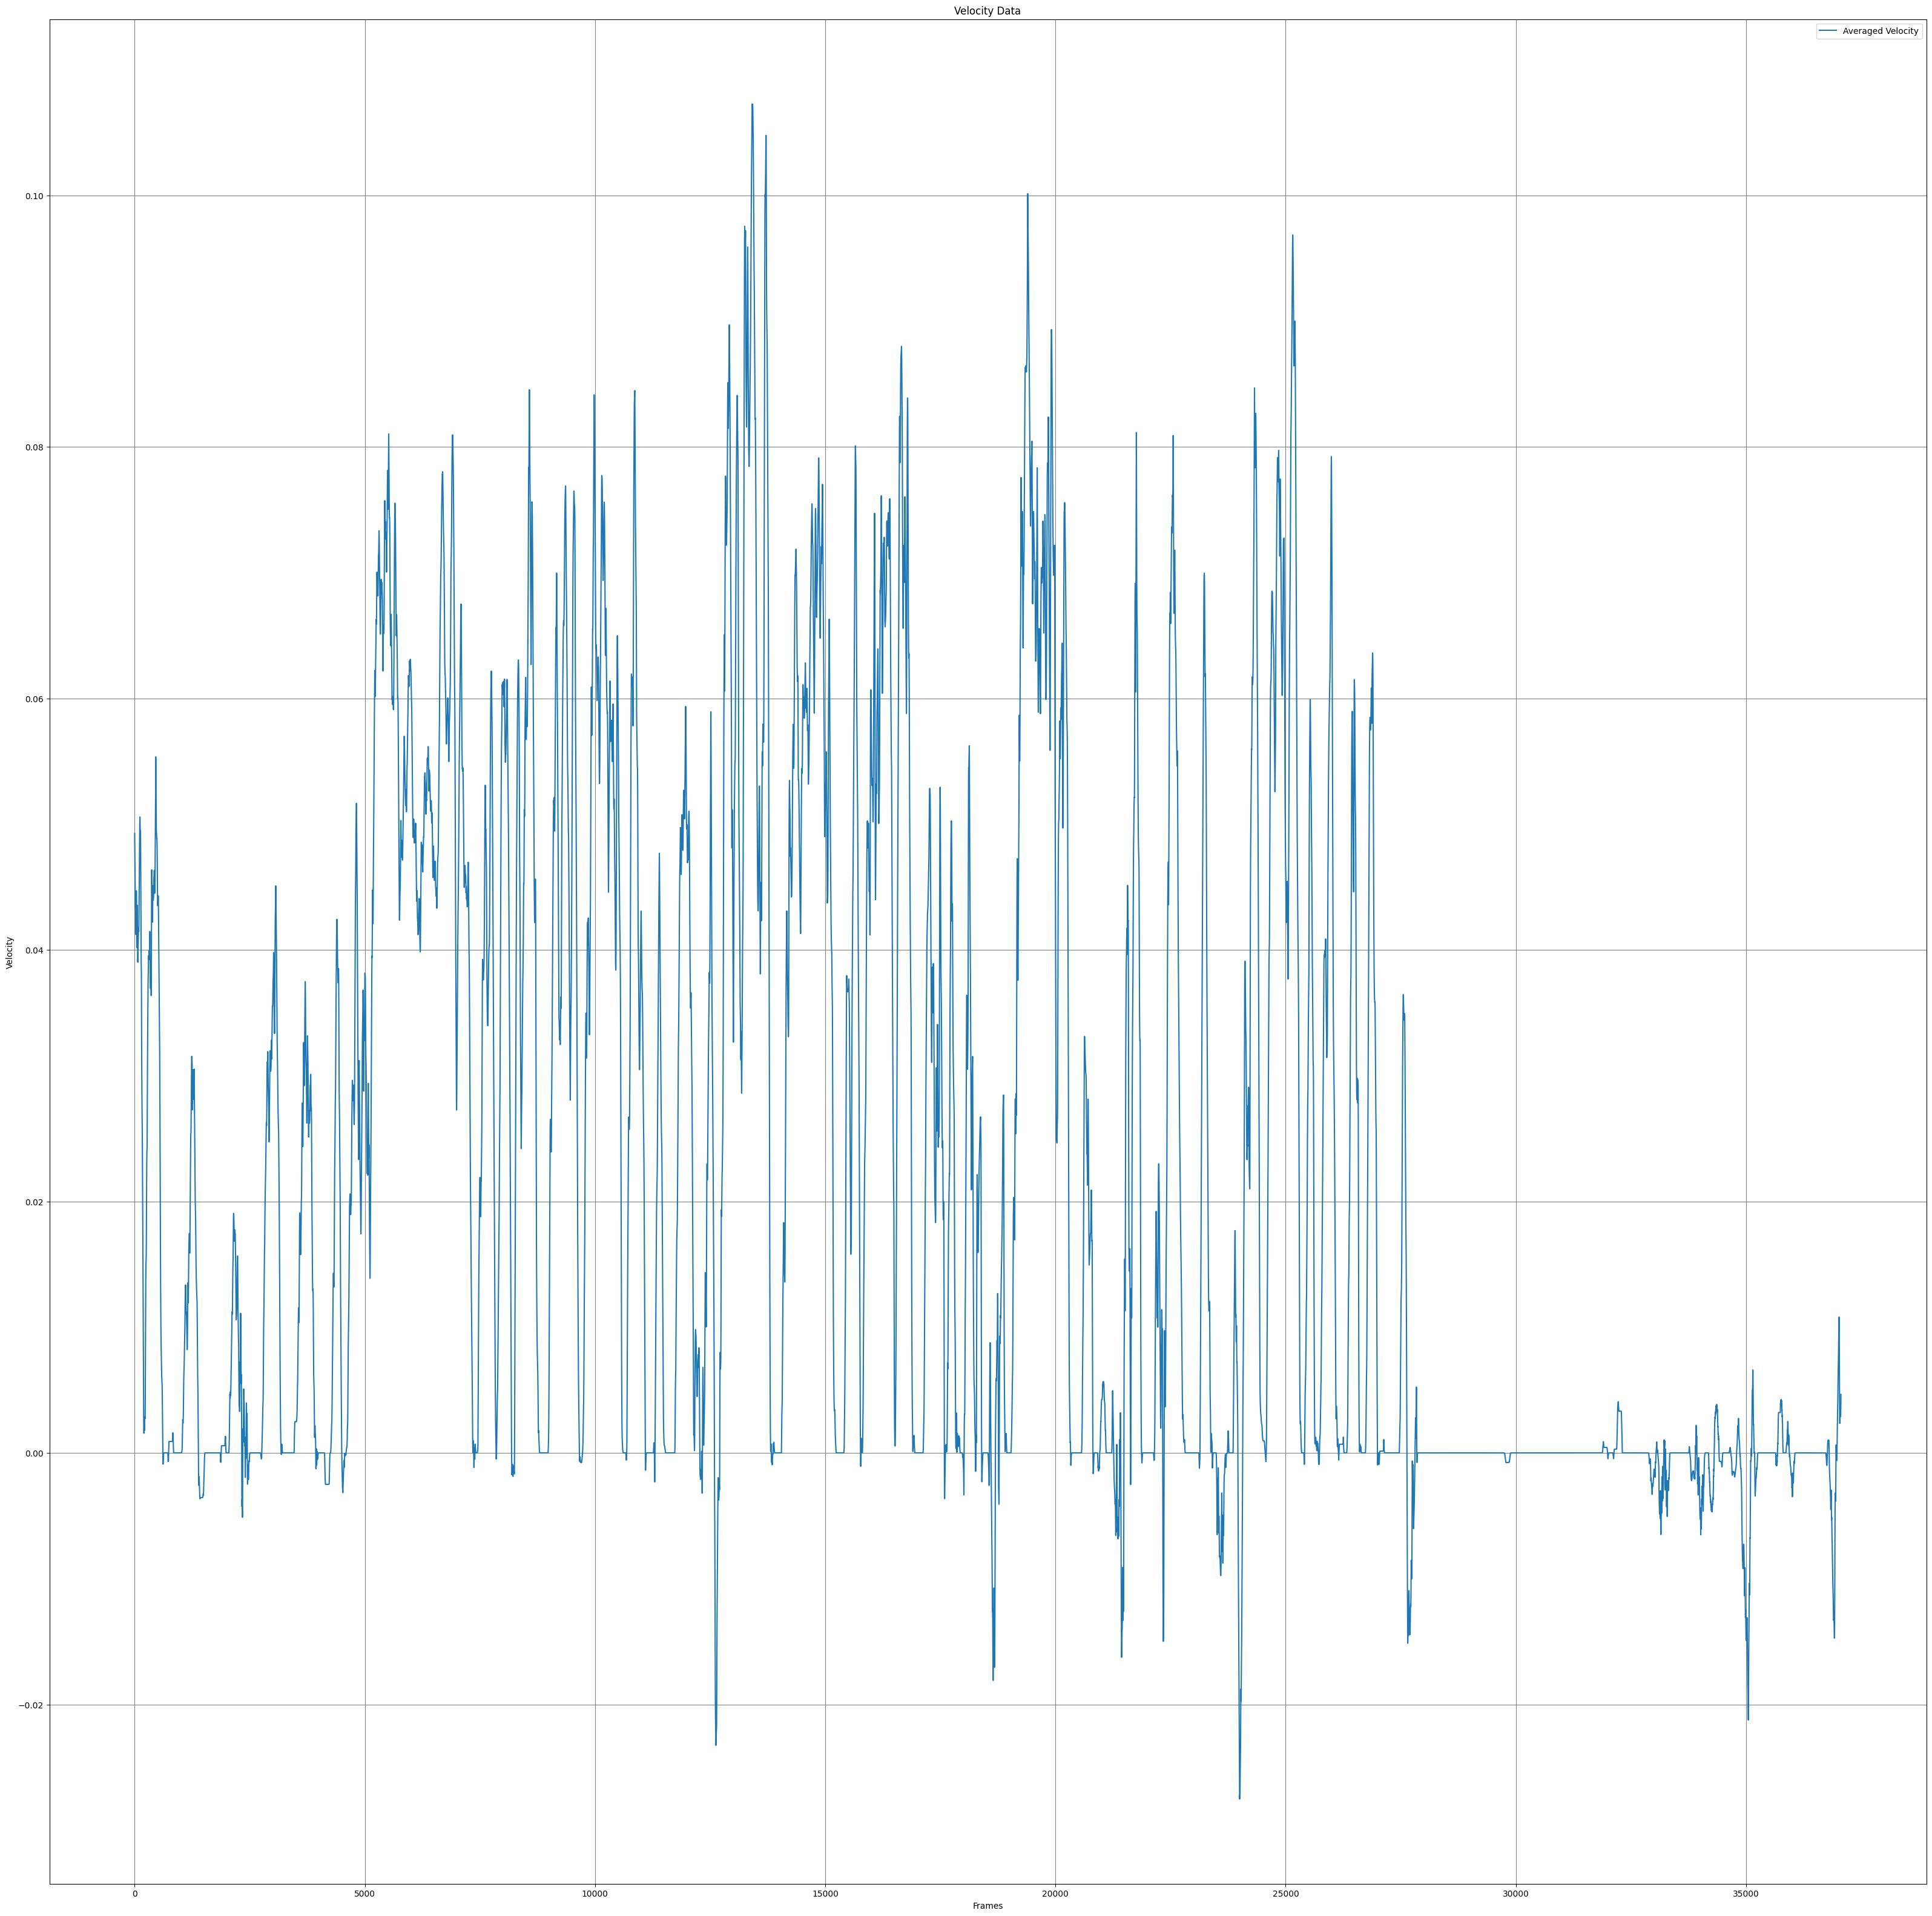

In [14]:
plot_velocity(velocity, average=True, window_size=100)